In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ugdatalab.models.apogee import APOGEEData, APOGEETrainingSet, APOGEESpectra
from ugdatalab.models.apogee.constants import LABEL_NAMES, LABEL_LATEX
from ugdatalab.models.apogee.spectra import (
    _get_apstar_spectra,
    _apply_bitmask,
    _normalize_spectrum,
)

import plotters

## Problem 1 — Training Set Selection

### Query APOGEE DR17 catalog

We query the APOGEE DR17 allStar catalog for four fields: M15 (metal-poor globular), NGC 6791 (metal-rich open cluster), a Kepler/K2 field, and a bulge field. This gives a range of stellar types and metallicities.

In [2]:
query = """
SELECT *
FROM apogeeStar AS s
JOIN aspcapStar AS a
    ON s.apstar_id = a.apstar_id
WHERE s.field IN ('M15', 'N6791', 'K2_C4_168-21', '060+00')
"""

source = APOGEEData(query)

### Apply quality cuts

We select a training set by requiring:
- All 5 ASPCAP labels (Teff, log g, [Fe/H], [Mg/Fe], [Si/Fe]) finite and not the ASPCAP NULL sentinel ($-9999$)
- SNR $> 50$
- $\log g \leq 4$ and $T_{\rm eff} \leq 5700\,\mathrm{K}$ (giants only)
- $[\mathrm{Fe/H}] \geq -1$

In [3]:
training = APOGEETrainingSet(source)

### Surface gravity calculation

Surface gravity is $g = GM/R^2$. For a solar-mass star:

$$\log g = \log g_\odot + \log\left(\frac{M}{M_\odot}\right) - 2\log\left(\frac{R}{R_\odot}\right)$$

where $\log g_\odot = 4.44$ (CGS). Typical evolutionary stages:

| Stage | $R/R_\odot$ | $\log g$ |
|---|---|---|
| Main sequence | $\sim 1$ | $\sim 4.44$ |
| Pre-He flash (tip RGB) | $\sim 100$ | $\sim 0.44$ |
| Core He burning (red clump) | $\sim 15$ | $\sim 2.08$ |

The $\log g \leq 4$ cut selects evolved stars (giants and subgiants), excluding the main sequence. Most of our sample will be red giants on the RGB or in the red clump.

### Label corner plot

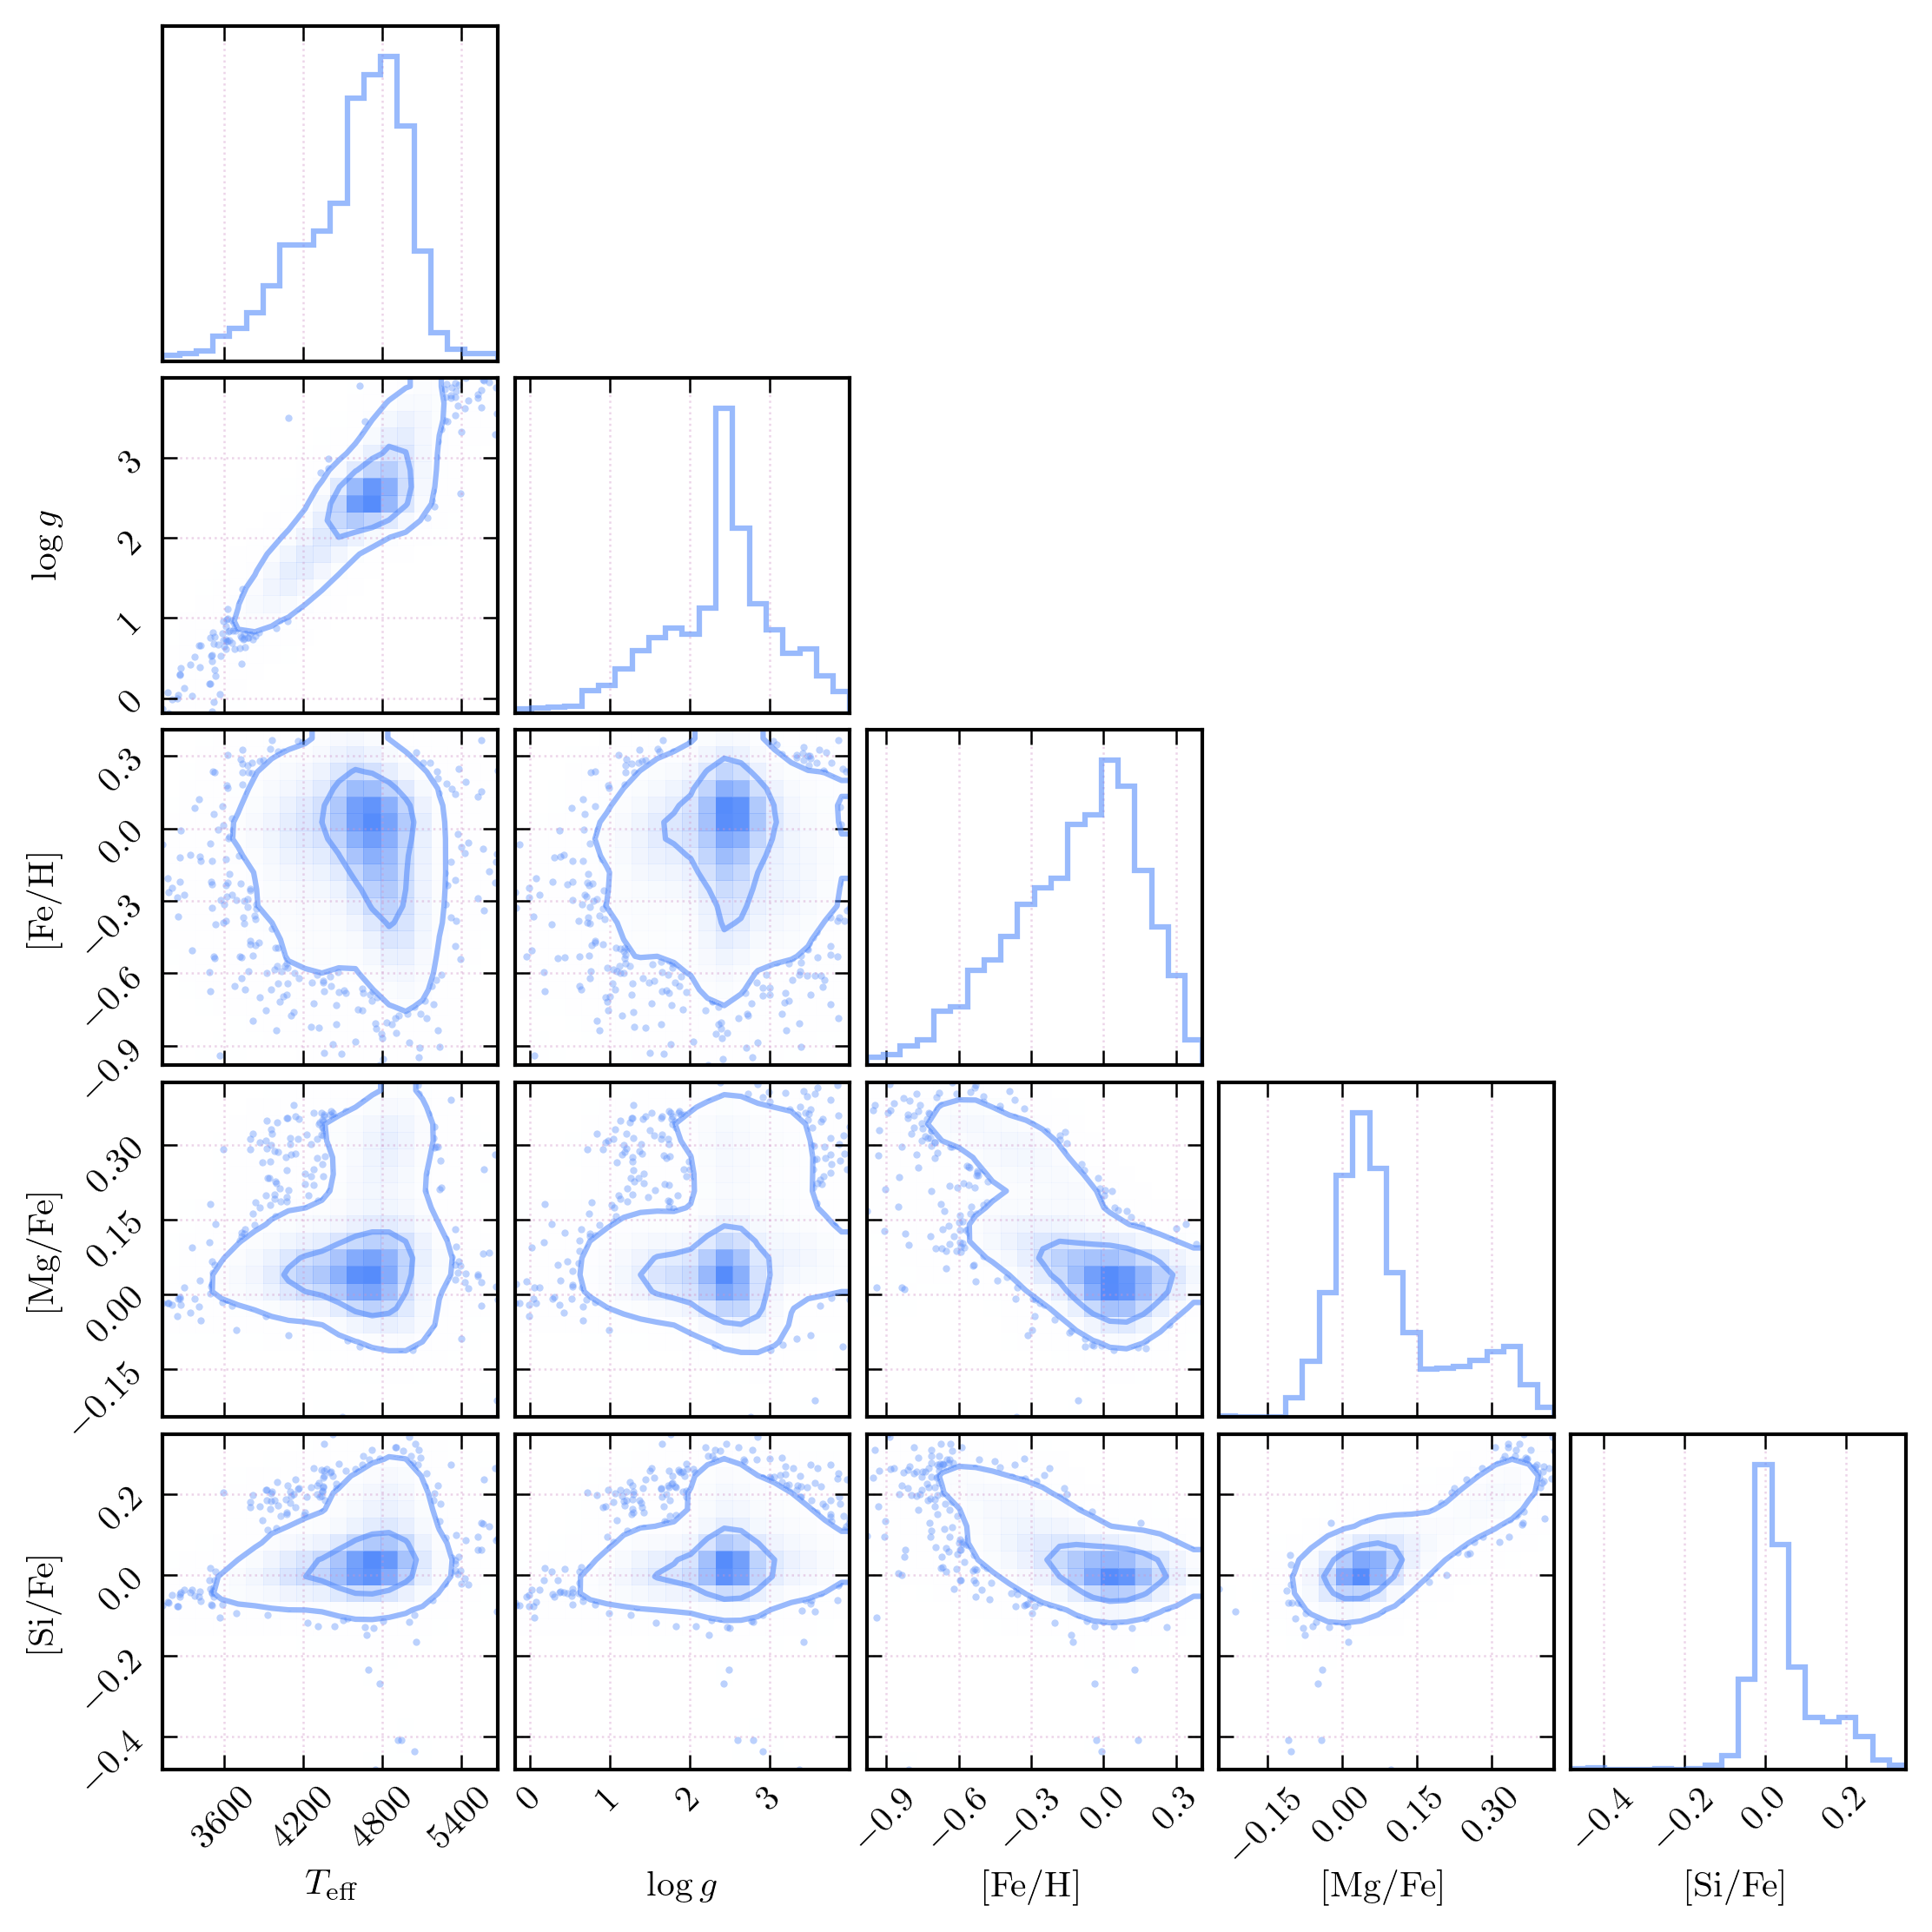

In [4]:
label_cols = ["teff", "logg", "fe_h", "mg_fe", "si_fe"]
labels = np.column_stack([training.data[col] for col in label_cols])

fig = plotters.plot_label_corner(labels, LABEL_LATEX)
plt.show()

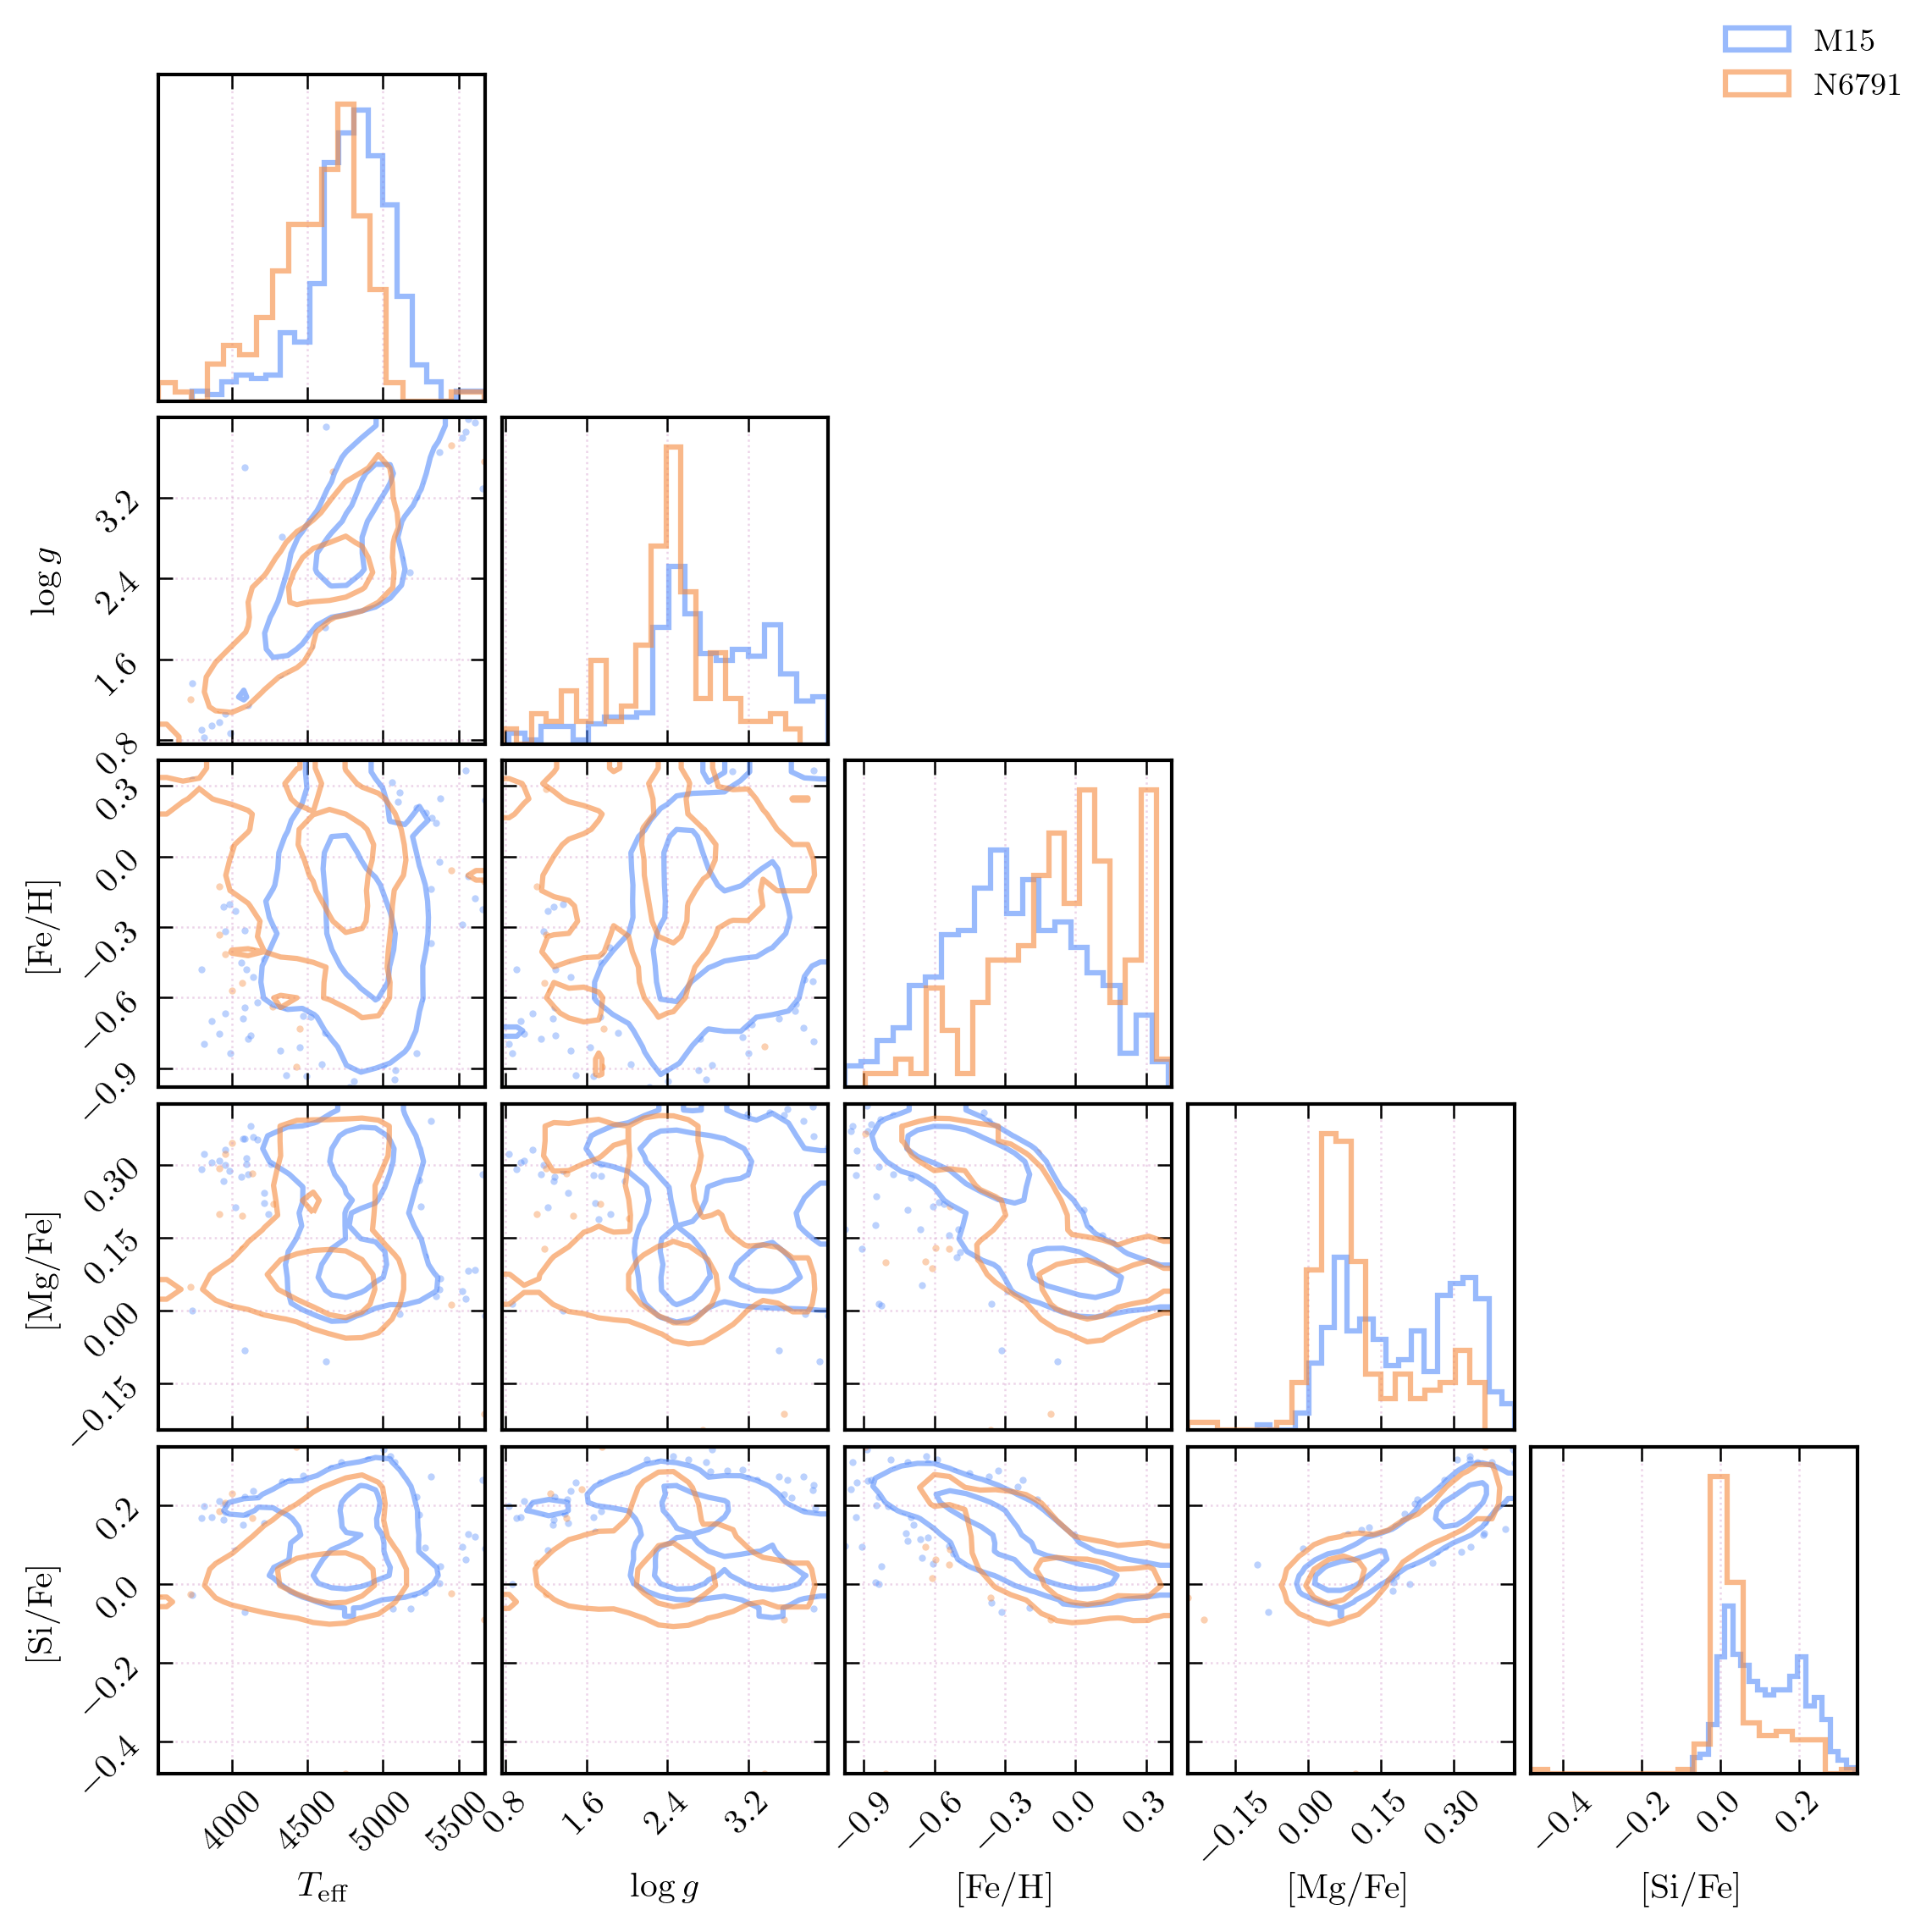

In [5]:
fields = np.array(training.data["field"], dtype=str)
mask = np.isin(fields, ["M15", "N6791"])
fig = plotters.plot_label_corner_by_field(labels[mask], LABEL_LATEX, fields[mask])
plt.show()

## Problem 2 — Download Spectra

### Raw spectrum example

We download one spectrum to examine before normalization. APOGEE spectra are in units of $10^{-17}\,\mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}$ (spectral flux density) on a barycentric wavelength grid — observed wavelengths corrected for Earth's orbital motion so that absorption features appear at their rest wavelengths.

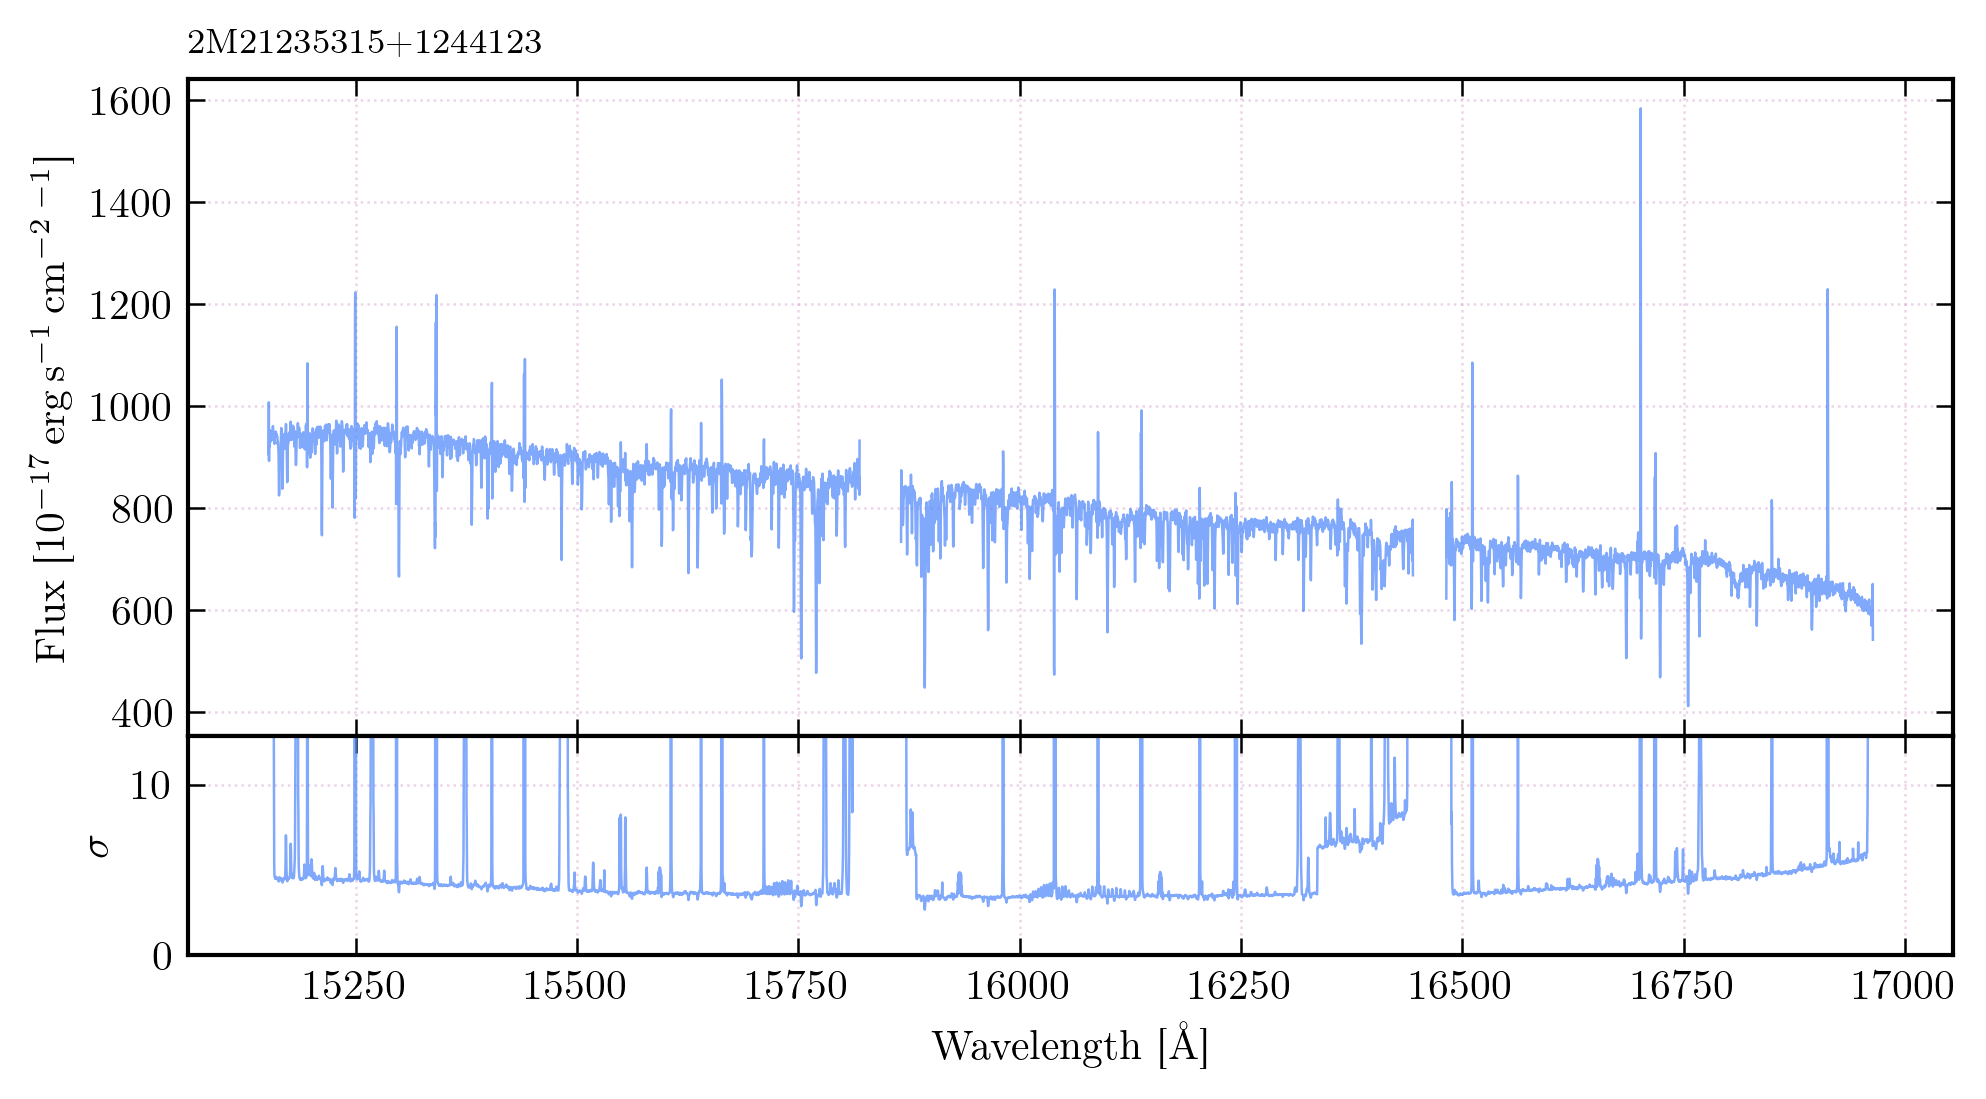

In [6]:
example_id = "2M21235315+1244123"
example_row = training.data[np.array(training.data["apogee_id"], dtype=str) == example_id]
spec_raw = _get_apstar_spectra(
    example_id,
    str(example_row["telescope"][0]),
    str(example_row["field"][0]),
)

axes = plotters.plot_example_spectrum(
    spec_raw["wavelength"], spec_raw["flux"], spec_raw["error"], apogee_id=example_id,
)
plt.show()

## Problem 3 — Pixel Bitmask

The APOGEE pixel bitmask (`APOGEE_PIXMASK`) flags problematic pixels. We mask the following bits by setting $\sigma_\lambda = \infty$ (zero weight in any $\chi^2$ fit):

| Bit | Name | Description |
|-----|------|-------------|
| 0 | `BADPIX` | Pixel marked bad in the detector dark frame |
| 1 | `CRPIX` | Cosmic ray hit identified in the up-the-ramp sampling |
| 2 | `SATPIX` | Pixel saturated in a significant number of reads |
| 3 | `UNFIXABLE` | Pixel flagged bad and could not be fixed by interpolation |
| 4 | `BADDARK` | Bad pixel in the dark current subtraction |
| 5 | `BADFLAT` | Bad pixel in the flat-field calibration |
| 6 | `BADERR` | Pixel with unreliable error estimate |
| 7 | `NOSKY` | Sky subtraction failed at this pixel |
| 12 | `NODATA` | No data collected (inter-chip gap or unvisited pixel) |

Setting $\sigma_\lambda = \infty$ for flagged pixels gives them zero weight ($1/\sigma^2 = 0$) in any subsequent chi-squared fit, effectively masking them without discarding the entire spectrum.

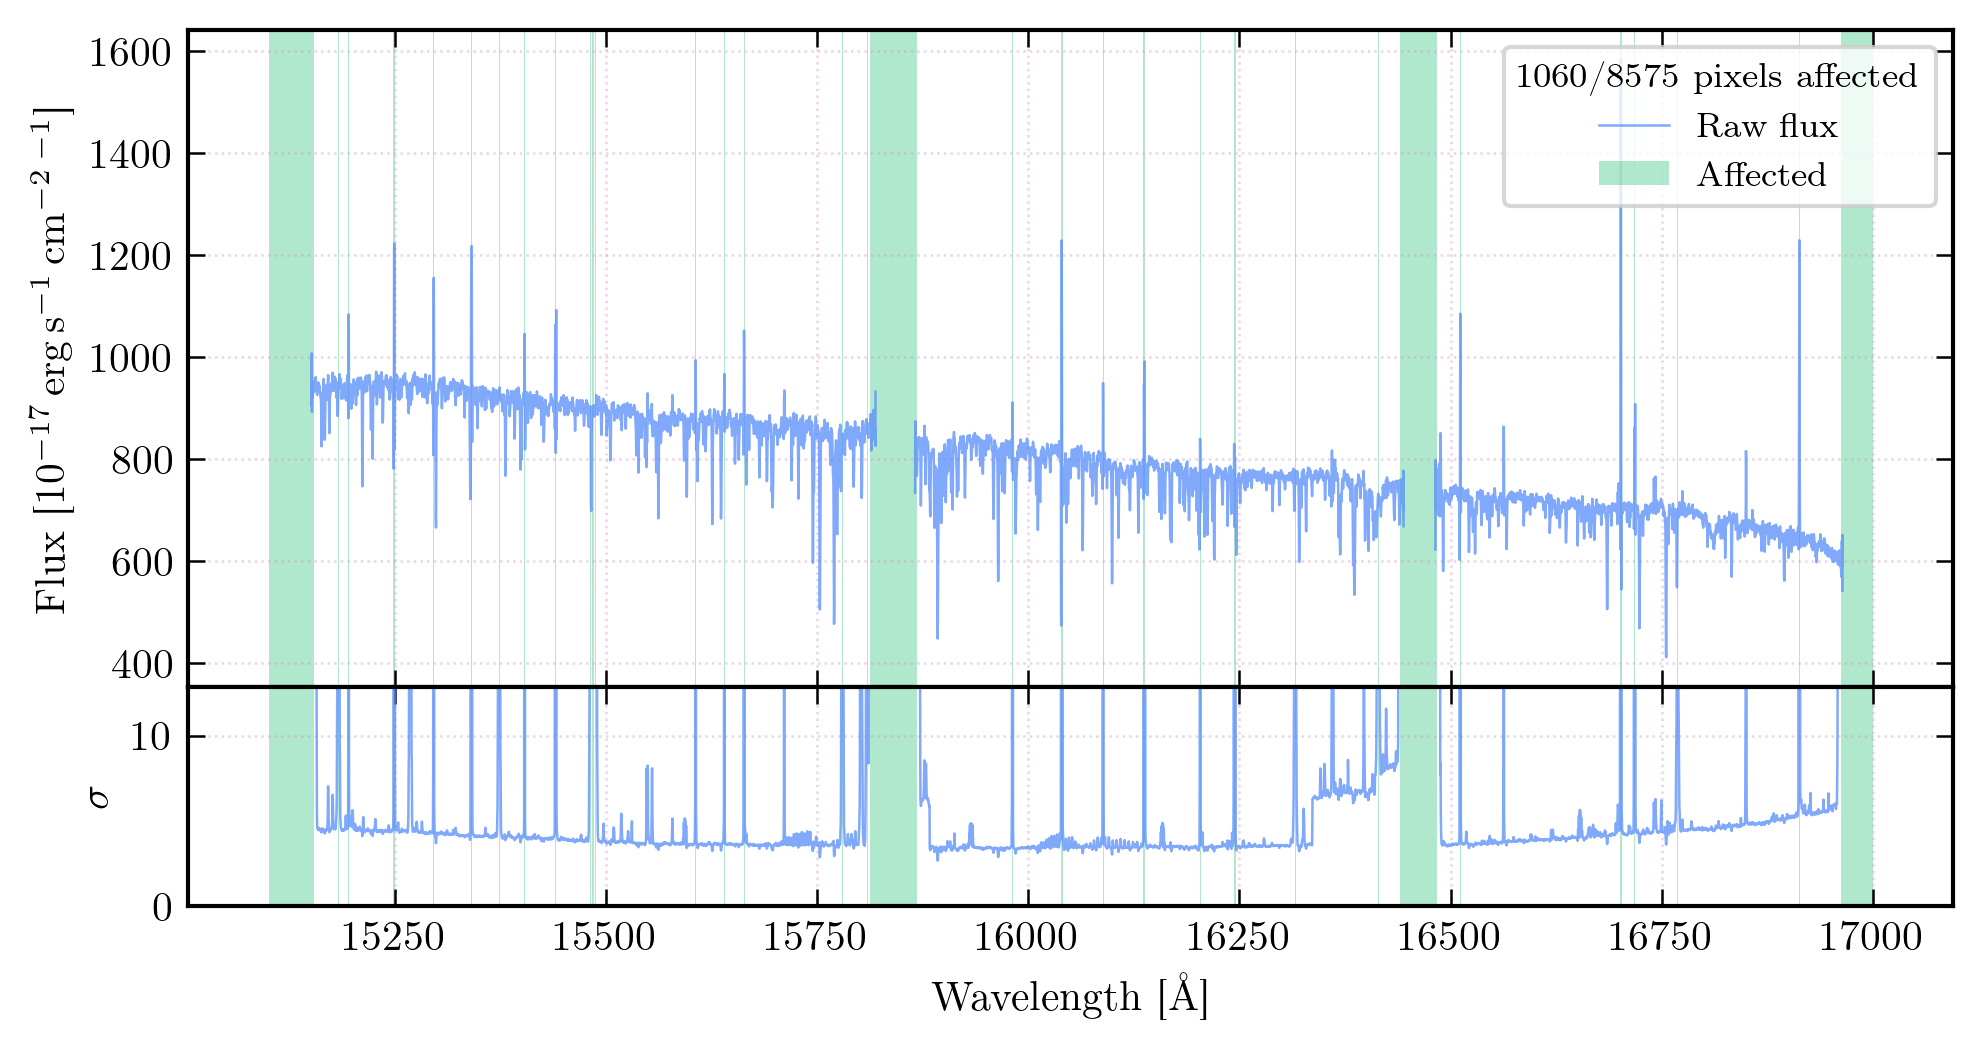

In [7]:
ax = plotters.plot_bitmask_diagnostic(
    spec_raw["wavelength"], spec_raw["flux"], spec_raw["error"], spec_raw["bitmask"],
)
plt.show()

## Problem 4 — Pseudo-Continuum Normalization

Pseudo-continuum normalization divides each spectrum by a smooth estimate of the underlying continuum level. "Pseudo" because we use empirically identified continuum pixels — wavelengths where the flux does not depend on stellar labels — rather than a physical stellar atmosphere model for the true continuum. This removes the broadband SED shape (set by effective temperature and the instrument's blaze function) so that spectral features can be modeled as fractional deviations from unity.

We fit an independent degree-4 Chebyshev polynomial to each of the three APOGEE chips (blue, green, red), using only the 529 pre-identified continuum pixels. Each chip gets its own polynomial — no polynomial spans across inter-chip gaps.

### Normalization diagnostic

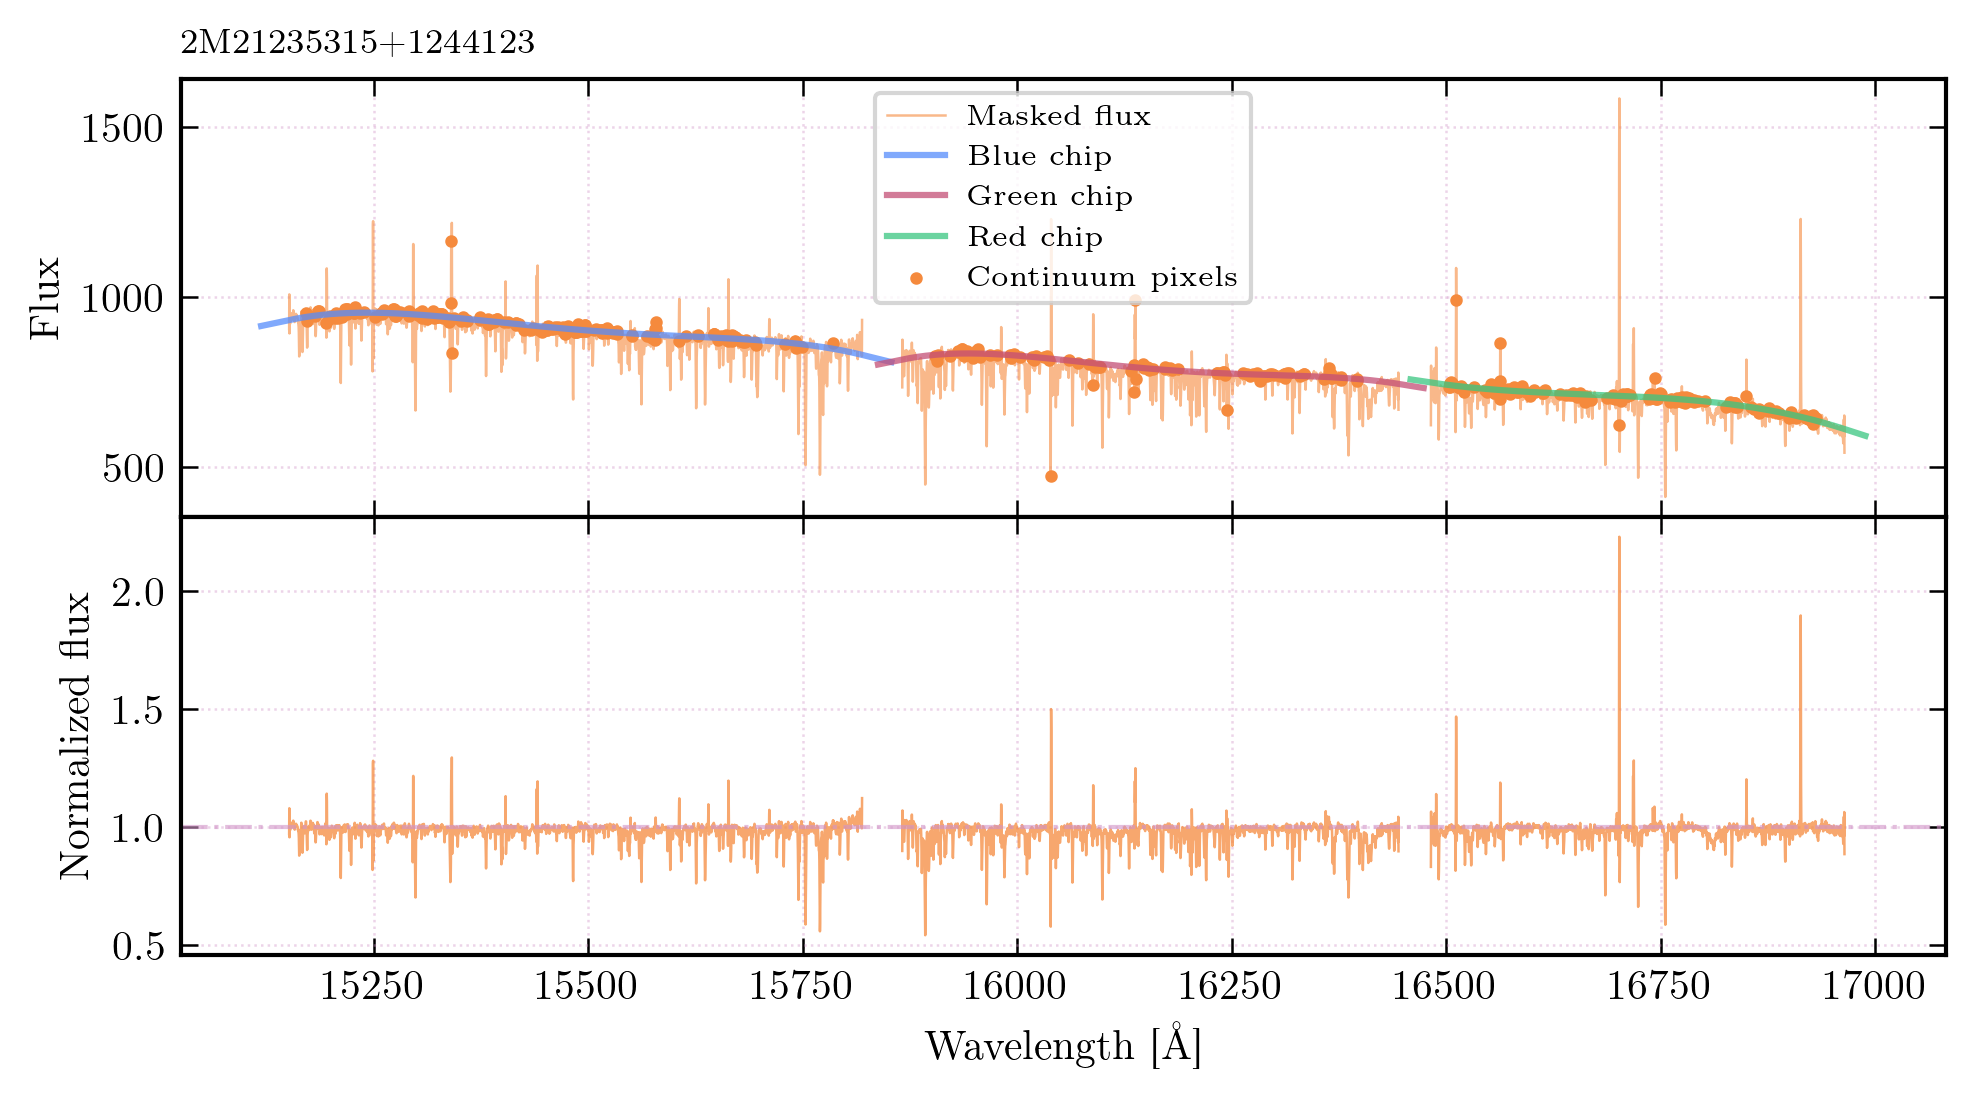

In [8]:
continuum_path = Path("continuum_wavelengths.npz")
continuum_data = np.load(continuum_path)
continuum_mask = continuum_data["continuum"].astype(bool)
wavelength = continuum_data["wavelengths"]

flux_masked, error_masked = _apply_bitmask(
    spec_raw["flux"], spec_raw["error"], spec_raw["bitmask"],
)
flux_norm, error_norm, continuum_fit = _normalize_spectrum(
    flux_masked, error_masked, wavelength, continuum_mask,
    spec_raw["chips"], degree=4,
)

axes = plotters.plot_normalization_diagnostic(
    wavelength, flux_masked, error_masked,
    continuum_fit, flux_norm, error_norm, continuum_mask,
    apogee_id=example_id,
)
plt.show()

### Download and normalize all training spectra

In [9]:
spectra = APOGEESpectra(source=training, continuum_path=continuum_path)
print(f"Flux shape: {spectra.flux.shape}")
print(f"Error shape: {spectra.error.shape}")
print(f"Wavelength shape: {spectra.wavelength.shape}")
print(f"Stars downloaded: {len(spectra)}")

APOGEE spectra:   0%|          | 0/1886 [00:00<?, ?it/s]

Flux shape: (1886, 8575)
Error shape: (1886, 8575)
Wavelength shape: (8575,)
Stars downloaded: 1886


### Bitmask frequency across training set

How often is each pixel masked across all training spectra? Persistent spikes indicate detector regions that are systematically flagged (dead pixels, chip edges).

APOGEE spectra:   0%|          | 0/1886 [00:00<?, ?it/s]

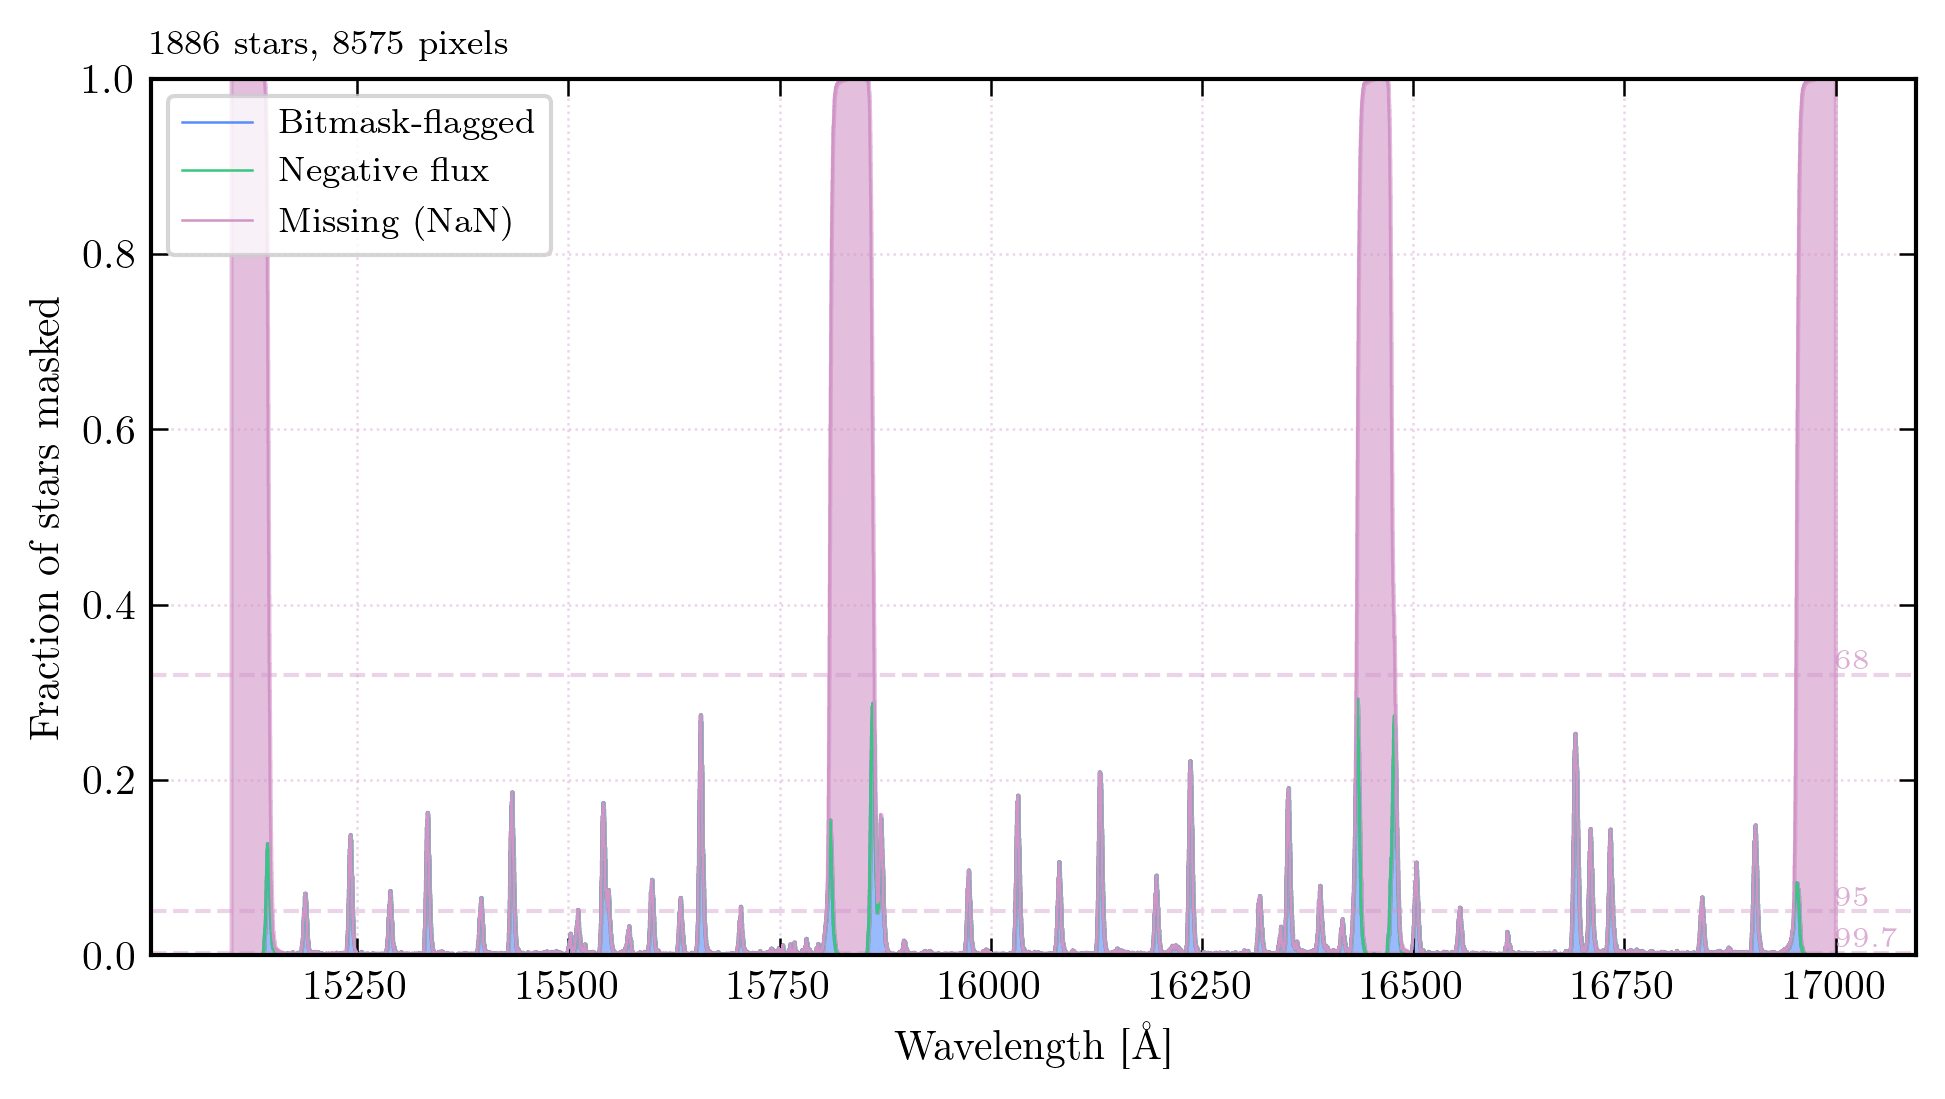

In [10]:
from ugdatalab.models.apogee.spectra import _fetch_apstar_batch

raw_spectra = _fetch_apstar_batch(training.data)
flux_raw_all = np.array([s["flux"] for s in raw_spectra])
bitmask_raw_all = np.array([s["bitmask"] for s in raw_spectra])

ax = plotters.plot_bitmask_frequency(spectra.wavelength, flux_raw_all, bitmask_raw_all)
plt.show()

In [11]:
from ugdatalab.models.apogee.constants import APOGEE_BAD_PIXMASK_BITS
import pandas as pd

n_stars, n_pixels = flux_raw_all.shape

nan_mask = np.isnan(flux_raw_all)
bm_mask = np.zeros_like(flux_raw_all, dtype=bool)
for bit in APOGEE_BAD_PIXMASK_BITS:
    bm_mask |= (bitmask_raw_all & (1 << bit)).astype(bool)
bm_mask &= ~nan_mask
neg_mask = (flux_raw_all < 0) & ~nan_mask & ~bm_mask
good_mask = ~nan_mask & ~bm_mask & ~neg_mask

good_per_px = np.sum(good_mask, axis=0)
bm_per_px = np.sum(bm_mask, axis=0)
neg_per_px = np.sum(neg_mask, axis=0)
nan_per_px = np.sum(nan_mask, axis=0)

good_frac = good_per_px / n_stars

summary = pd.DataFrame({
    "Category": [
        "100% good",
        "≥ 99.7% good",
        "≥ 95% good",
        "≥ 68% good",
        "Any bitmask-flagged",
        "Any negative flux",
        "Any missing (NaN)",
    ],
    "Pixels": [
        np.sum(good_frac == 1.0),
        np.sum(good_frac >= 0.997),
        np.sum(good_frac >= 0.95),
        np.sum(good_frac >= 0.68),
        np.sum(bm_per_px > 0),
        np.sum(neg_per_px > 0),
        np.sum(nan_per_px > 0),
    ],
})
summary["% of pixels"] = (summary["Pixels"] / n_pixels * 100).map("{:.1f}%".format)

print(f"Pixel breakdown ({n_pixels} total, {n_stars} stars):")
summary

Pixel breakdown (8575 total, 1886 stars):


,Category,Pixels,% of pixels
0,100% good,294,3.4%
1,≥ 99.7% good,4398,51.3%
2,≥ 95% good,6998,81.6%
3,≥ 68% good,7712,89.9%
4,Any bitmask-flagged,7808,91.1%
5,Any negative flux,40,0.5%
6,Any missing (NaN),1194,13.9%


The spikes in the bitmask frequency correspond to known instrumental and atmospheric features, not stellar signals:

- **Chip gaps** (~15130, ~15840, ~16460, ~16975 Å): all stars are masked at the physical boundaries between APOGEE's three H2RG detectors, where no data is recorded.
- **~15852 Å**: a cluster of bright **OH airglow emission lines** from Earth's upper atmosphere. The sky subtraction pipeline (`NOSKY`, bit 7) fails here because the airglow intensity varies on timescales shorter than the exposure.
- **~16452–16468 Å**: **telluric CO$_2$ absorption** near the green–red chip boundary, compounded by reduced detector sensitivity at the chip edge.
- **~16975 Å**: the **red edge** of APOGEE's wavelength coverage, where detector quantum efficiency drops and strong **telluric H$_2$O absorption** contaminates the signal.

The absence of spikes at known stellar absorption features (e.g., Brackett series, Fe I, Mg I) confirms that the bitmask is correctly targeting instrumental and atmospheric artifacts rather than astrophysical signal.

### Robustness check — similar stars comparison

Stars with similar labels should produce nearly identical normalized spectra. Significant differences would indicate problems with the continuum normalization.

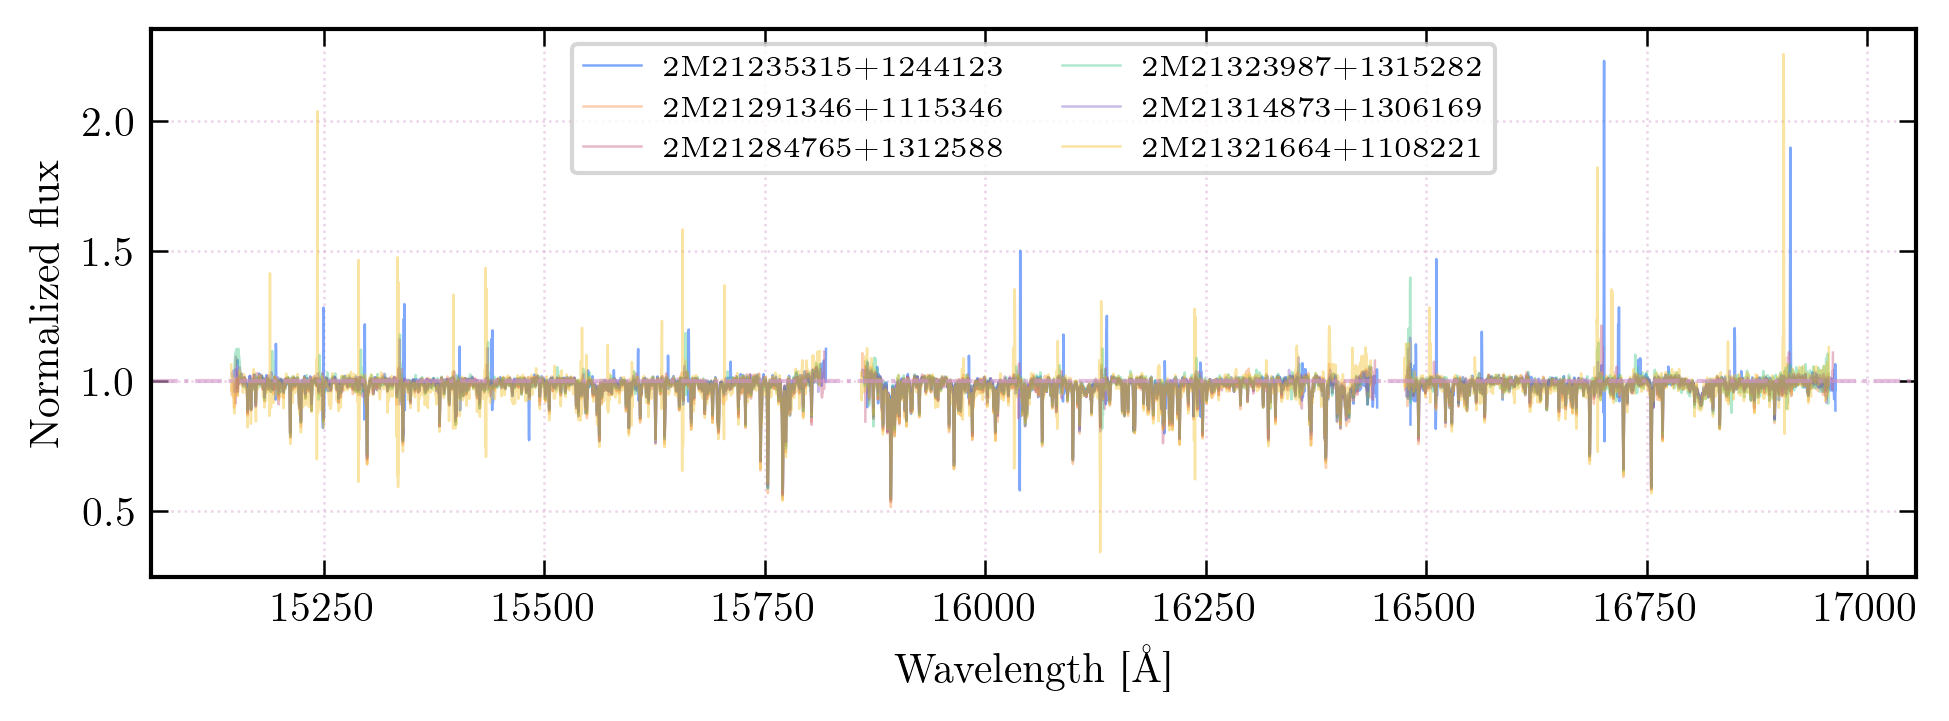

In [12]:
# The spectra are downloaded in catalog order, so apogee_ids matches training.data order.
# Build label array directly from catalog order.
label_cols = ["teff", "logg", "fe_h", "mg_fe", "si_fe"]
spec_labels = np.column_stack([training.data[col] for col in label_cols])

# Use the example star as reference
ref_idx = int(np.where(spectra.apogee_ids == example_id)[0][0])

ax = plotters.plot_similar_stars_comparison(
    spectra.wavelength, spectra.flux, spectra.error,
    spec_labels, spectra.apogee_ids, ref_idx, n_similar=5,
)
plt.show()

### Save training spectra

In [13]:
# Labels are in catalog order (same as spectra download order)
labels_all = np.column_stack([training.data[col] for col in label_cols])
starflag = np.array(training.data["starflag"])
aspcapflag = np.array(training.data["aspcapflag"])

np.savez_compressed(
    "training_spectra.npz",
    wavelength=spectra.wavelength,
    flux=spectra.flux,
    error=spectra.error,
    labels=labels_all,
    label_names=np.array(LABEL_NAMES),
    apogee_ids=spectra.apogee_ids,
    continuum_mask=spectra.continuum_mask,
    starflag=starflag,
    aspcapflag=aspcapflag,
)
print("Saved training_spectra.npz")
print(f"  flux: {spectra.flux.shape}")
print(f"  labels: {labels_all.shape}")
print(f"  stars: {len(spectra)}")

Saved training_spectra.npz
  flux: (1886, 8575)
  labels: (1886, 5)
  stars: 1886
